**Name-Ujjawal chauhan 
roll no-62 'B'
cu24250259
Labsheet=07**

In [26]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [27]:
cap = cv2.VideoCapture("56310-479197605.mp4")

if not cap.isOpened():
    print("Error: Video not found!")
else:
    print("Video loaded successfully!")

Video loaded successfully!


In [28]:
ret, old_frame = cap.read()

if not ret:
    print("Error: Could not read first frame!")
else:
    print("First frame read successfully!")

print("Frame size:", old_frame.shape)

First frame read successfully!
Frame size: (1080, 1920, 3)


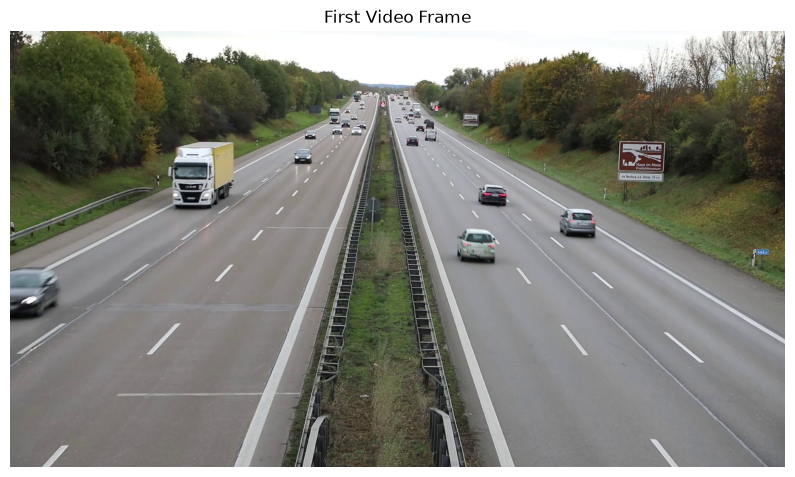

In [29]:
old_rgb = cv2.cvtColor(old_frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 6))
plt.imshow(old_rgb)
plt.title("First Video Frame")
plt.axis("off")
plt.show()

In [30]:
old_gray = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)

feature_params = dict(
    maxCorners=100,
    qualityLevel=0.3,
    minDistance=7,
    blockSize=7
)

p0 = cv2.goodFeaturesToTrack(
    old_gray,
    mask=None,
    **feature_params
)

print("Number of feature points detected:", len(p0))

Number of feature points detected: 100


In [31]:
lk_params = dict(
    winSize=(15, 15),
    maxLevel=2,
    criteria=(
        cv2.TERM_CRITERIA_EPS |
        cv2.TERM_CRITERIA_COUNT,
        10,
        0.03
    )
)

# Read next frame
ret, frame = cap.read()

if ret:
    frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Calculate Lucas-Kanade optical flow
    p1, st, err = cv2.calcOpticalFlowPyrLK(
        old_gray,
        frame_gray,
        p0,
        None,
        **lk_params
    )

    # Select successfully tracked points
    good_new = p1[st == 1]
    good_old = p0[st == 1]

    # Draw motion vectors
    output_lk = frame.copy()

    for new, old in zip(good_new, good_old):

        x_new, y_new = new.ravel()
        x_old, y_old = old.ravel()

        x_new, y_new = int(x_new), int(y_new)
        x_old, y_old = int(x_old), int(y_old)

        # Draw arrow
        cv2.arrowedLine(
            output_lk,
            (x_old, y_old),
            (x_new, y_new),
            (255, 255, 255),
            2,
            tipLength=0.3
        )

        # Draw feature point
        cv2.circle(
            output_lk,
            (x_new, y_new),
            4,
            (255, 255, 255),
            -1
        )

    print("Lucas-Kanade Optical Flow calculated!")
else:
    print("Could not read next frame.")

Lucas-Kanade Optical Flow calculated!


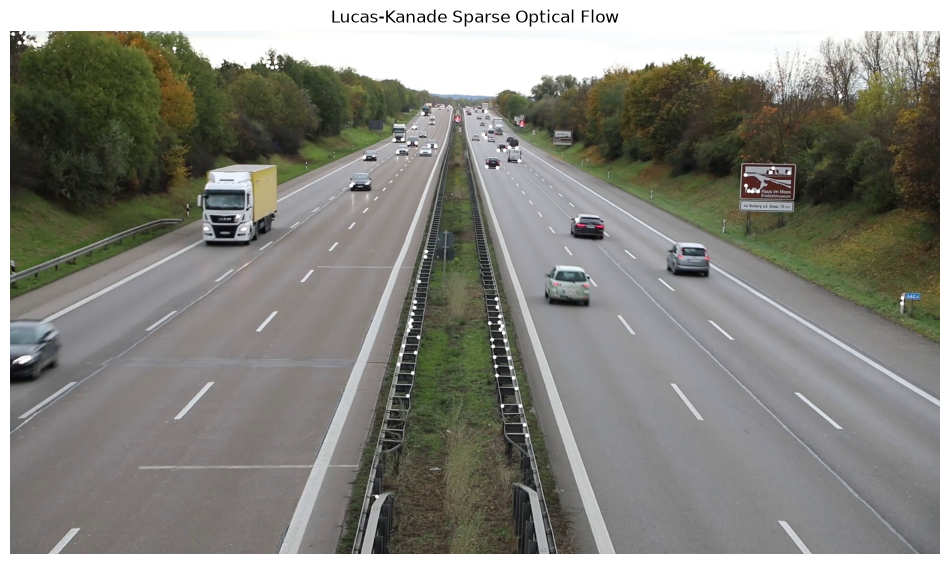

In [32]:
lk_rgb = cv2.cvtColor(output_lk, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 7))
plt.imshow(lk_rgb)
plt.title("Lucas-Kanade Sparse Optical Flow")
plt.axis("off")
plt.show()

In [33]:
# Calculate Farneback Dense Optical Flow

flow = cv2.calcOpticalFlowFarneback(
    old_gray,
    frame_gray,
    None,
    0.5,
    3,
    15,
    3,
    5,
    1.2,
    0
)

print("Farneback Dense Optical Flow calculated!")

Farneback Dense Optical Flow calculated!


In [34]:
# Convert flow into magnitude and angle
magnitude, angle = cv2.cartToPolar(
    flow[..., 0],
    flow[..., 1]
)

# Create HSV image
hsv = np.zeros_like(frame)

# Saturation
hsv[..., 1] = 255

# Direction
hsv[..., 0] = angle * 180 / np.pi / 2

# Magnitude
hsv[..., 2] = cv2.normalize(
    magnitude,
    None,
    0,
    255,
    cv2.NORM_MINMAX
)

# Convert HSV to BGR
dense_output = cv2.cvtColor(
    hsv,
    cv2.COLOR_HSV2BGR
)

print("Dense optical flow visualization created!")

Dense optical flow visualization created!


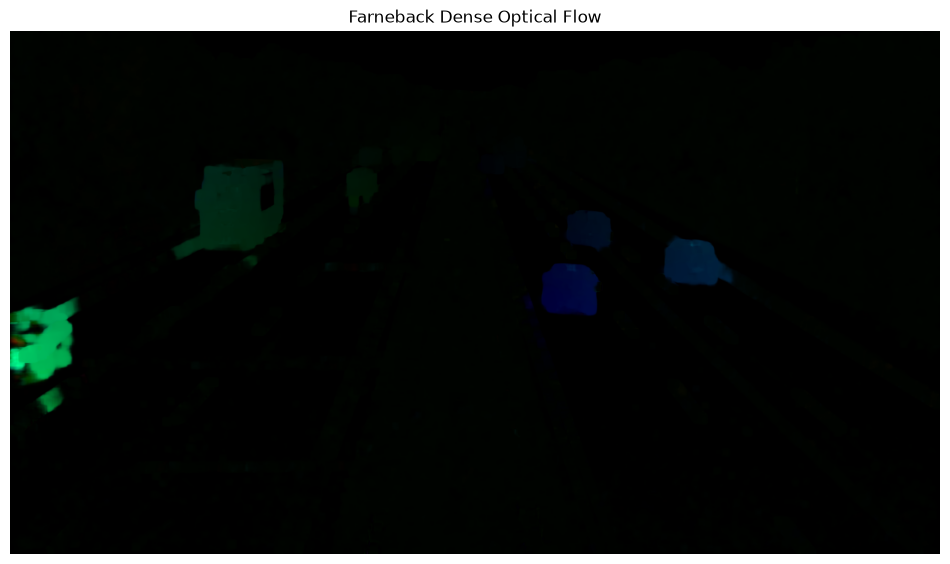

In [35]:
dense_rgb = cv2.cvtColor(
    dense_output,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(12, 7))
plt.imshow(dense_rgb)
plt.title("Farneback Dense Optical Flow")
plt.axis("off")
plt.show()